<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan4_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 4 — Statistika Dasar & Analisis Data
## Eksplorasi Statistik Dataset Iris

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Pengantar Data Science (200302305) |
| **Pertemuan** | 4 — Statistika Dasar & Analisis Data |


## Langkah 1 — Load & Inspect Dataset

Memuat dataset Iris menggunakan `seaborn.load_dataset()`, lalu menampilkan shape, dtypes, lima baris pertama, dan ringkasan statistik `.describe()`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print()
print(df.dtypes)

Shape: (150, 5)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [2]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe().round(3)

,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


**Interpretasi:** Dataset terdiri dari 150 baris dan 5 kolom — empat kolom numerik (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`, semuanya `float64` dalam cm) dan satu kolom kategorik `species`. Tidak ada missing value (count = 150 di semua kolom). Rentang nilai paling lebar ada pada `petal_length` (1.0–6.9 cm).

## Langkah 2 — Statistik Deskriptif Lengkap

Menghitung mean, median, standar deviasi, varians, skewness, dan kurtosis untuk setiap kolom numerik.

In [4]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Varians  : {col.var():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')
    print()

=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Varians  : 0.686
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Varians  : 0.190
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Varians  : 3.116
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Varians  : 0.581
  Skewness : -0.103
  Kurtosis : -1.341



**Interpretasi:**

- `sepal_length`: skewness 0.315 (−0.5 s.d. 0.5) → distribusi **relatif simetris**; mean (5.843) sedikit di atas median (5.8).
- `sepal_width`: skewness 0.319 → relatif simetris; kurtosis positif kecil menandakan ekor sedikit lebih tebal dari normal.
- `petal_length`: skewness −0.275, tetapi kurtosis sangat negatif (−1.402) → puncak datar/ekor tipis, indikasi distribusi **bimodal** (kelompok setosa terpisah dari dua spesies lain).
- `petal_width`: pola serupa petal_length, kurtosis −1.341 → juga bimodal.

## Langkah 3 — Analisis Distribusi (Histogram + KDE)

Histogram + KDE untuk `sepal_length` dengan garis mean dan median, untuk mengidentifikasi jenis distribusinya.

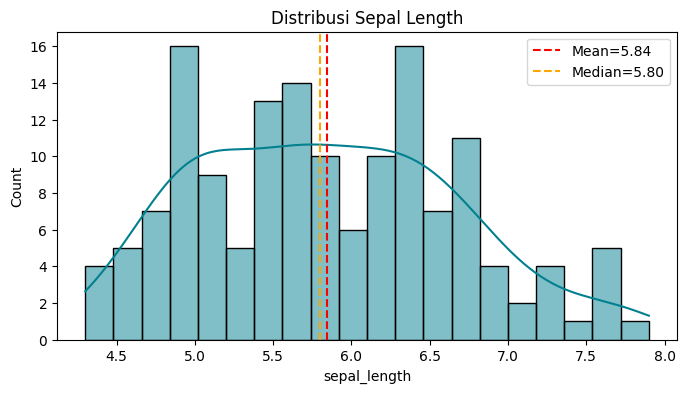

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
           linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
           linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

**Interpretasi:** Mean (5.84) dan median (5.80) hampir berimpit, dengan skewness 0.315 yang masih dalam rentang −0.5 s.d. 0.5. Distribusi `sepal_length` tergolong **mendekati normal / simetris**, dengan kemiringan ke kanan yang sangat ringan (mean > median).

## Langkah 4 — Boxplot per Spesies

Boxplot dan violin plot `petal_length` per spesies untuk membandingkan distribusi antar kelompok.

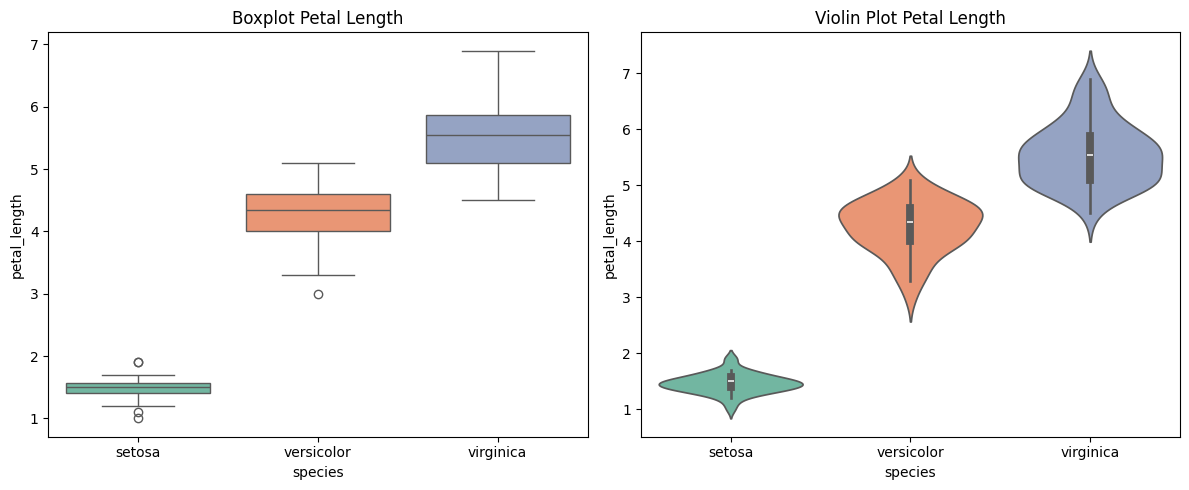

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
            hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',
               hue='species', palette='Set2', inner='box',
               legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

In [7]:
print(df.groupby('species')['petal_length'].agg(['min','median','max','std']).round(3))

            min  median  max    std
species                            
setosa      1.0    1.50  1.9  0.174
versicolor  3.0    4.35  5.1  0.470
virginica   4.5    5.55  6.9  0.552


**Interpretasi:**

- **Nilai terbesar**: *virginica* (median ≈ 5.55 cm, maksimum 6.9 cm).
- **Nilai terkecil**: *setosa* (median ≈ 1.50 cm) — terpisah jelas dari dua spesies lain tanpa tumpang tindih.
- **Paling tersebar**: *virginica* (std ≈ 0.552, IQR terlebar); *setosa* paling seragam (std ≈ 0.174). Pemisahan tegas inilah penyebab pola bimodal pada Langkah 2.

## Langkah 5 — Matriks Korelasi Pearson

Menghitung matriks korelasi Pearson antar kolom numerik, lalu mengidentifikasi pasangan dengan korelasi tertinggi dan terendah.

In [8]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
pairs = corr_masked.stack()
max_pair = pairs.idxmax()
min_pair = pairs.idxmin()
print(f'\nKorelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah : {min_pair} = {corr.loc[min_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963
Korelasi terendah : ('petal_length', 'sepal_width') = -0.428


**Interpretasi:** Korelasi **tertinggi** adalah `petal_length` ↔ `petal_width` (r = 0.963, sangat kuat positif) — bunga dengan mahkota panjang hampir pasti mahkotanya juga lebar. Korelasi **terendah** adalah `sepal_width` ↔ `petal_length` (r = −0.428, negatif lemah). `sepal_width` satu-satunya variabel yang berkorelasi negatif terhadap ketiga variabel lain.

## Langkah 6 — Scatter Plot & Heatmap

Scatter plot pasangan paling berkorelasi (`petal_length` vs `petal_width`) dengan garis regresi, disandingkan dengan heatmap korelasi lengkap.

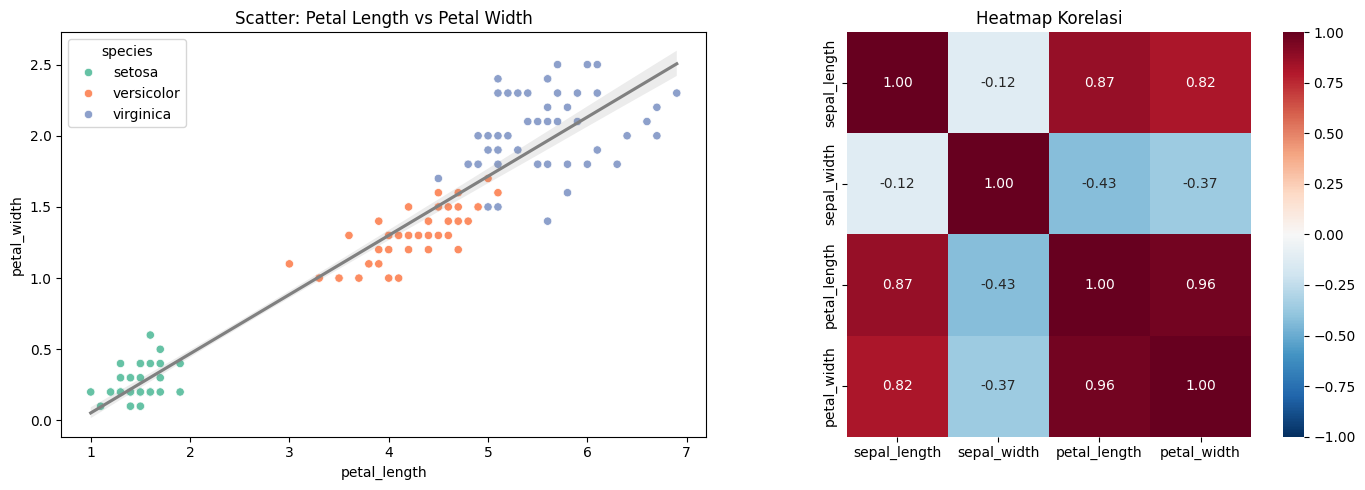

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

**Narasi Interpretasi:**

Scatter plot memperlihatkan hubungan **linear positif sangat kuat** antara `petal_length` dan `petal_width` (r = 0.963): titik-titik rapat di sekitar garis regresi. Tiga spesies membentuk klaster berurutan — *setosa* (kecil, terisolasi di kiri bawah), *versicolor* (menengah), *virginica* (besar) — sehingga ukuran petal sangat efektif untuk membedakan spesies.

Heatmap mengonfirmasi: `petal_length`/`petal_width` juga berkorelasi kuat dengan `sepal_length` (0.87 dan 0.82), sedangkan `sepal_width` berkorelasi negatif lemah terhadap semuanya. Perlu diingat **korelasi tidak berarti kausalitas** — korelasi kuat antar ukuran di sini lebih mencerminkan perbedaan ukuran antar spesies (variabel ketiga) daripada hubungan sebab-akibat langsung.

**Kesimpulan:** Statistika deskriptif, analisis distribusi, dan analisis bivariat secara konsisten menunjukkan bahwa fitur petal adalah pembeda utama antar spesies Iris, sementara `sepal_width` adalah fitur yang paling independen.